In [12]:
import pandas as pd
import re
import spacy
import kagglehub

nlp = spacy.load("en_core_web_sm")

def first_n_words(text, n=35):
    words = text.split()
    return ' '.join(words[:n])

def cut_to_n_sentences(text):
    doc = nlp(text)
    return ' '.join([sent.text for sent in (list(doc.sents)[:2] + list(doc.sents)[-2:])])

_CLEAN_RE = re.compile(r"[^A-Za-z\s]+")   # non-letters

def parse_text(df):
    return df.str.replace(_CLEAN_RE, "", regex=True)

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
real = pd.read_csv(f"{path}/True.csv")
fake = pd.read_csv(f"{path}/Fake.csv")

fake["label"] = 0   # Fake
real["label"] = 1   # Real

df_concat = pd.concat([fake, real], ignore_index=True)
df_concat["text"] = df_concat["text"].map(first_n_words)
df_concat["text"] = df_concat["title"] + " " + df_concat["text"]
df_concat = df_concat[["text", "label"]]

df = df_concat.sample(frac=1, random_state=42).reset_index(drop=True)

test = df["text"].iloc[:1000].map(first_n_words)
testlen = test.map(len)
testend = test.map(lambda x : x[-45:])
print(test)
print(testlen)
print(testend)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
0      Ben Stein Calls Out 9th Circuit Court: Committ...
1      Trump drops Steve Bannon from National Securit...
2      Puerto Rico expects U.S. to lift Jones Act shi...
3      OOPS: Trump Just Accidentally Confirmed He Lea...
4      Donald Trump heads for Scotland to reopen a go...
                             ...                        
995    Path cleared for Congress to consider U.S. arm...
996    Democrats urge full review before Senate vote ...
997    WHY PICTURE OF CHE-OBAMA Was Much Worse Than A...
998    #Berkeley CRAZY! RIOTERS CHASE And Beat People...
999    Democratic senators urge speed on Supreme Cour...
Name: text, Length: 1000, dtype: object
0      226
1      250
2      224
3      246
4      227
      ... 
995    231
996    221
997    234
998    217
999    237
Name: text, Length: 1000, dtype: int64
0      some Hollywood fame appearing in TV shows and
1      ng his controversial decision ea

In [13]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [22]:
import numpy as np

def _to_list_of_str(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        return [texts]

    return ["" if t is None else str(t) for t in texts]

def tokenize(texts):
    texts = _to_list_of_str(texts)
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

def predict(texts):
    texts = _to_list_of_str(texts)
    with torch.no_grad():
        inputs = tokenize(texts)
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()

@torch.inference_mode()
def predict_torch(texts):
    # SHAP może podać: list[str] albo np.array(dtype=object)
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
        max_length=256,
    )

    # KLUCZ: przenieś WSZYSTKIE tensory na device modelu
    enc = {k: v.to(device) for k, v in enc.items()}

    out = model(**enc)

    # zależnie od modelu: out.logits albo out[0]
    logits = out.logits if hasattr(out, "logits") else out[0]
    probs = torch.softmax(logits, dim=-1)

    # SHAP oczekuje numpy na CPU
    return probs.detach().cpu().numpy()

def predict_tokens(tokens):
    with torch.no_grad():
        outputs = model(**tokens)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    return probs

In [23]:
import torch
import numpy as np
from tqdm import tqdm

def batch_encodings(test_encodings, first, last):
    batch_input_ids = test_encodings['input_ids'][first:last]
    batch_attention_mask = test_encodings['attention_mask'][first:last]
    batch_token_type_ids = test_encodings['token_type_ids'][first:last]

    return {
        'input_ids': batch_input_ids,
        'attention_mask': batch_attention_mask,
        'token_type_ids': batch_token_type_ids
    }

TEST_N_BATCHES = 8

test_encodings = tokenize(test_texts)
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

batch_size = 16
test_labels = test_labels[:TEST_N_BATCHES * batch_size]

# Define a batch size for inference to prevent OutOfMemory errors
predictions = []

# Get the total number of test samples
num_samples = test_encodings['input_ids'].shape[0]

with torch.no_grad():
    # for i in tqdm(range(0, num_samples, batch_size)):
    for i in tqdm(range(0, batch_size * TEST_N_BATCHES, batch_size)):
        # Extract batch from test_encodings
        batch = batch_encodings(test_encodings, i, i + batch_size)

        # Perform inference on the batch
        outputs = model(**batch)
        batch_predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_predictions)

# Convert the list of predictions to a numpy array
predictions = np.array(predictions)

100%|██████████| 8/8 [00:01<00:00,  4.45it/s]


In [24]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}\n")
print(classification_report(test_labels, predictions, target_names=["Fake", "Real"]))

Test Accuracy: 0.9141

              precision    recall  f1-score   support

        Fake       0.85      1.00      0.92        62
        Real       1.00      0.83      0.91        66

    accuracy                           0.91       128
   macro avg       0.92      0.92      0.91       128
weighted avg       0.93      0.91      0.91       128



In [25]:
import shap

BG_N = 20

background_texts = pd.concat([
    fake.sample(BG_N, random_state=42),
    real.sample(BG_N, random_state=42)
])['text'].dropna().tolist()

In [26]:
eval_texts = df['text'].dropna().tolist()[:2]
print(eval_texts)

masker = shap.maskers.Text(
    tokenizer=None,
#   mask_token=tokenizer.mask_token,
)

explainer = shap.Explainer(
    predict_torch,
    masker,
    output_names=['fake', 'real'],
    algorithm='partition',
    data=background_texts,
)

shap_values = explainer(eval_texts)

['Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge', 'Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role']


In [28]:
def top_words(shap_values, n=1, sample_idx=0, class_idx=0, top_k=10):
    dfs = []

    for sample_idx in range(n):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        df = pd.DataFrame({
            "token": tokens,
            "importance": values
        })

        df = df[df.token.str.strip() != ""]
        df["abs"] = df.importance.abs()

        dfs.append(df.sort_values("abs", ascending=False).head(top_k))

    return dfs

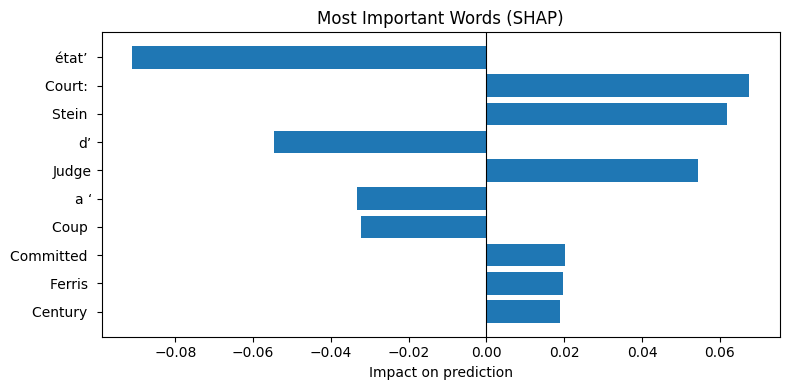

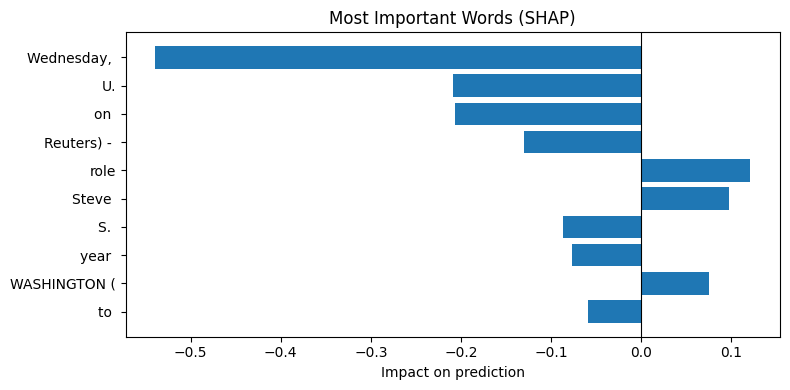

In [30]:
import matplotlib.pyplot as plt

def plot_top_words(dfs):
    for i in range(len(dfs)):
        plt.figure(figsize=(8, 4))
        plt.barh(
            dfs[i].token[::-1],
            dfs[i].importance[::-1]
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title("Most Important Words (SHAP)")
        plt.xlabel("Impact on prediction")
        plt.tight_layout()
        plt.show()

plot_top_words(top_words(shap_values, 2))

In [31]:
N_TEXTS = 100
texts = df_concat['text'].dropna().tolist()[:N_TEXTS]

shap_values = explainer(texts)

PartitionExplainer explainer: 101it [02:14,  1.44s/it]


In [33]:
import copy

N_TEXTS = 100
texts = df_concat['text'].dropna().tolist()[:N_TEXTS]
values_sorted = [np.argsort(shap_arr.T[0]) for shap_arr in shap_values.values]

first_prediction = predict_torch(texts)
current_prediction = copy.deepcopy(first_prediction)

current_texts = copy.deepcopy(texts)
new_texts = copy.deepcopy(texts)

eps = 1e-5

np.sum(np.argmax(first_prediction, axis = 1))

np.int64(2)

In [34]:
current_words = copy.deepcopy(list(shap_values.data))
new_words = copy.deepcopy(list(shap_values.data))

print(current_words[0])

[' ' 'Donald ' 'Trump ' 'Sends ' 'Out ' 'Embarrassing ' 'New ' 'Year’'
 's ' 'Eve ' 'Message; ' 'This ' 'is ' 'Disturbing ' 'Donald ' 'Trump '
 'just ' 'couldn ' 't ' 'wish ' 'all ' 'Americans ' 'a ' 'Happy ' 'New '
 'Year ' 'and ' 'leave ' 'it ' 'at ' 'that. ' 'Instead, ' 'he ' 'had '
 'to ' 'give ' 'a ' 'shout ' 'out ' 'to ' 'his ' 'enemies, ' 'haters '
 'and ' 'the ' 'very ' 'dishonest ' 'fake ' 'news']


In [35]:
for candidate_num in range(10):
    for i in range(N_TEXTS):
        values = values_sorted[i]
        candidate_idx = values[candidate_num]

        new_words[i][candidate_idx] = re.sub(r'^\s', '', new_words[i][candidate_idx])

        new_text = ''.join(new_words[i])
        new_texts[i] = new_text

    new_prediction = predict_torch(new_texts)
    influence = (current_prediction - new_prediction).T[0]
    print(new_words[0][candidate_idx])
    print(influence[0])
    print(new_texts[0])

    for i in range(N_TEXTS):
        if influence[i] > 0:
            current_texts[i] = new_texts[i]
            current_prediction[i] = new_prediction[i]
            current_words[i] = new_words[i]

second_prediction = predict(texts)
np.sum(np.argmax(first_prediction, axis = 1)), np.sum(np.argmax(second_prediction, axis = 1))

Year’
Started 
Eye’ 
Trump 
condemned 
by 
84th 
Saturday 
He’
group 
s 
further 
Wednesday, 
cabinet, 
cking 
all 
audio-
White 
United 
R-
biggest 
METOO 
Jones’ 
have 
launched 
Would ‘
remained 
and 
on 
Thursday, 
is 
he 
Wednesday, 
formally 
Thousands’ 
Roy 
U.
Trump’
of 
Sunday, 
his 
at 
Election’ 
to 
Up’ 
suggest 
and 
Britain, 
contested. 
It’
Mueller’
Leader’
13-
Trump’
children. 
not 
to 
as 
Harry’
Monday, 
and 
be 
would 
He’
Y’
December 
even 
That’
declined 
San 
Won’
website 
Over ‘
s 
paid 
year-
has 
Their ‘
Him – 
China 
billion 
week, 
his 
Country’
Zealand’
about 
or 
He’
Rule – 
Thursday, 
Having 
a 
a 
has 
in 
Called 
On 
s 
Didn’
Monday 
0.0
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news
very 
under 
Friday, 
Obama’
Speech 
no 
spent 
Said 
autocrat. 


RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)